In [1]:
# Load the extension
%load_ext autoreload
# Set to reload all modules (except those explicitly excluded) before executing user code
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/aleksei/projects/code-of-kutulu-client')

In [3]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def viz_map(env_map, entities):
    curr_map = [list(line) for line in env_map]
    for e in entities:
        curr_map[e['y']][e['x']] = e['type'][0]
        if e['type'] == 'EXPLORER':
            curr_map[e['y']][e['x']] = str(e['id'])
    curr_map = [''.join(line) for line in curr_map]
    for line in curr_map:
        print(line)

In [5]:
def rollout(env, seed, verbose=False, can_wait=True):
    info = env.reset(seed)
    rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
#         action = [4, 4, 4, 4]
        entities, reward, game_over, info = env.step(action)
        if verbose:
            viz_map(env.map, entities)
        rewards.append(reward)
    return rewards

In [6]:
from src.envs.kutulu_world import KutuluWorldEnv, DEFAULT_KUTULU_ACTIONS
from src.envs.distance import find_path
from src.envs.kutulu_player import KutuluPlayer
from src.envs.strategy import RandomStrategy, GreedyStrategy, LazyGreedyStrategy

In [7]:
env = KutuluWorldEnv(
    server_host='localhost:8080',
    maze_name="Hypersonic",
    league_level=1,
    players_count=4,
)

In [12]:
player = KutuluPlayer(env)

In [37]:
pi = LazyGreedyStrategy()
eps=0.05
alpha=0.1
gamma=0.99
num_experiments=100
can_wait=True
verbose=False

In [38]:
Q = pi.Q
reward_list = []

In [45]:
for _ in tqdm(range(num_experiments)):
    observation, info = env.reset()
    rollout_rewards = []
    game_over = False
    while not game_over:
        state = player.get_state(0, max_explorer_dist=5, max_wanderer_dist=5)
        player_mask = ~np.array(player.env.get_valid_action_mask()[0])
        At = pi.getActionEpsGreedyMasked(state, DEFAULT_KUTULU_ACTIONS, eps, player_mask)
        action = env.sample_valid_action(can_wait)
        action[0] = At
        entities, rewards, game_over, info = env.step(action)
        reward = rewards[0]
        
        if reward is None:
            break
        
        if game_over:
            Q[state][At] += alpha * (reward - Q[state][At])
            break

        Q[state][At] += alpha * (
            reward + gamma * Q[state].max() - Q[state][At]
        )
        
        if verbose:
            viz_map(env.map, entities['entities'])

        rollout_rewards.append(reward)
    reward_list.append(sum(rollout_rewards))

100%|██████████| 1000/1000 [07:16<00:00,  2.29it/s]


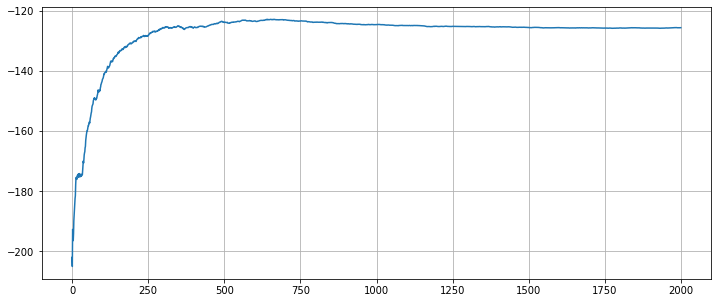

In [56]:
plt.figure(figsize=(12, 5))
sns.lineplot(np.cumsum(reward_list) / (np.arange(len(reward_list)) + 1))
_ = plt.grid()

In [154]:
import pickle as pkl
import zlib
import base64

In [166]:
len([k for k in pi.Q.keys()])

2743

In [186]:
new_keys = [k for k in pi.Q.keys() if ((k[1] or 0) < 8) and ((k[3] or 0) < 5)]

In [187]:
len(new_keys)

1185

In [188]:
data1 = pkl.dumps(np.array(list(pi.Q[k] for k in new_keys)))
data2 = pkl.dumps(list(new_keys))

In [191]:
# base64.b64encode(zlib.compress(data2, level=9))